<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/mini_money_cluster1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install gensim
!pip install pyLDAvis

import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 64.0 MB/s eta 0:00:00


In [4]:
import pickle

# 저장된 피클 파일 불러오기
with open('money.pkl', 'rb') as file:
    df = pickle.load(file)

# 데이터 프레임 확인
df

,time,review,token,vector,cluster
0,2023. 5. 30. 17:09,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...,"[나, 가계부, 지출, 년, 월, 생활비, 정산, 만, 원, 가계부, 인, 가구, ...","[0.30756757, 0.5918555, 0.461231, 0.046143718,...",0
1,2022. 10. 9. 22:41,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...,"[신혼부부, 가계부, 신혼부부, 가계부, 화목, 화목, 신혼부부, 가계부, 입당, ...","[0.27674928, 0.15712692, 0.13509633, 0.1298834...",0
2,2022. 7. 2. 4:34,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...,"[예금, 진실, 문득, 투자, 하다, 경제, 흐름, 알다, 왜, 예금, 하다, 단지...","[0.13865133, 0.23854105, -0.1422634, -0.244948...",1
3,2022. 7. 6. 5:19,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...,"[카카오, 뱅크, 청년, 전세, 자금, 대출, 연장, 년, 금리, 변동, 카카오, ...","[0.2509269, 0.23787966, 0.4049208, -0.05299510...",2
4,2022. 8. 15. 18:08,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...,"[탕, 다시다, 가다, 삼성, 병원, 가지, 베이컨, 그라탕, 해, 먹기, 미치다,...","[0.258239, 0.17201473, 0.14492722, -0.18530975...",0
...,...,...,...,...,...
1014,2022. 10. 11. 11:05,스물셋 으로 보는 월의 첫주 밸런스프렌즈 토글 리더스 나한테 많은 영감을 주는 쯔지...,"[스물, 셋, 보다, 월, 주, 밸런스, 프렌즈, 토글, 리더, 스, 나, 많다, ...","[0.63227224, 0.9904623, -0.20603919, 0.2416802...",1
1015,2023. 2. 5. 22:20,직장인 갓생 탤이의 갓생 겨울방학 끝 동분서주 바쁜 탤이 공주놀이 넘 즐거워 모...,"[직장인, 생, 탤이, 생, 겨울방학, 끝, 동분서주, 바쁘다, 탤, 공주, 넘다,...","[0.27612135, 0.4148776, 0.9310572, -0.10018817...",1
1016,2023. 4. 3. 14:11,청년전세임대주택 청약 일정 신청 서울특별시 순위로 청약 신청 위치한국토지주택공사...,"[청년, 전세, 임대주택, 청약, 일정, 신청, 서울특별시, 순위, 청약, 신청, ...","[0.29272598, -0.0033324107, -0.10790638, 0.482...",2
1017,2022. 9. 23. 1:20,외쳐 갓생 하이루이번 글 사진 레전드 많음 최대 장수 나의 갓생 시작 먹던 햄...,"[외치다, 생, 하이루, 이번, 글, 사진, 레전드, 많다, 최대, 장수, 나, 생...","[0.45119035, 0.5115195, 0.41722584, -0.2367723...",4


In [5]:
df_cluster = df.loc[df['cluster'] == 1]
df_cluster

,time,review,token,vector,cluster
2,2022. 7. 2. 4:34,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...,"[예금, 진실, 문득, 투자, 하다, 경제, 흐름, 알다, 왜, 예금, 하다, 단지...","[0.13865133, 0.23854105, -0.1422634, -0.244948...",1
6,2022. 6. 12. 12:31,드디어 개월 간의 학년 학기가 막을 내렸다개월간 나는 정말 쉬지 않고 달려...,"[개월, 간의, 학년, 학기, 막, 내리다, 개, 월간, 나, 정말, 쉬, 않다, ...","[-0.19683371, 0.5004393, -0.1806362, 0.0604078...",1
8,2022. 7. 24. 12:02,차 이번 주에 무엇을 했나요 주차 했다 갔다 샀다 먹었다 봤다 ...,"[차, 이번, 주, 무엇, 하다, 주차, 하다, 가다, 사다, 먹다, 보다, 등, ...","[-0.023139792, -0.14043787, 0.26085818, -0.231...",1
12,2023. 2. 5. 10:09,단어로 정리되는 들 단어로 정리되는 들 수요일 일요일 씨몽키 수요일 씨몽키 동생...,"[단어, 정리, 되다, 들다, 단어, 정리, 되다, 들다, 수요일, 일요일, 씨몽키...","[-0.074651465, -0.06962849, -0.0449293, 0.1176...",1
15,2022. 6. 18. 19:22,년 직장인 월 째주국장개미의 버티기 한주 자체 휴식을 갖고 돌아왔다카드값 리...,"[년, 직장인, 월, 째다, 국장, 개미, 버티다, 한주, 자체, 휴식, 갖다, 돌...","[0.0469142, 0.04694925, -0.05641458, 0.3088194...",1
...,...,...,...,...,...
998,2022. 6. 17. 19:01,월 퇴근하고 집가는 길에어 금요일이네싶어서 쓰는한의 모아보기주말에 이벤트가...,"[월, 퇴근, 지다, 길, 에어, 금요일, 싶다, 쓰다, 의, 모으다, 보다, 이벤...","[0.32922328, 0.084597826, 0.061621558, -0.0465...",1
1005,2023. 3. 13. 5:31,갓생한번살아보자 아침에 일어나서 이부정리하기 에 운동 시간하기 걷기 헬스 수영 윗몸...,"[생, 한번, 살, 보다, 아침, 일어나서, 이부, 정리, 하다, 운동, 시간, 하...","[0.09681317, 0.07073236, 0.23482051, 0.4940591...",1
1009,2022. 7. 15. 21:10,년 주 객관적인 은 나를 말해준다 주 한 월까지는 매주 수면과 자기계발 시간을...,"[년, 주, 객관, 은, 나르다, 말, 해주다, 주, 하다, 월, 수면, 자기계발,...","[-0.02636605, 1.2755141, -0.11121786, 0.673627...",1
1014,2022. 10. 11. 11:05,스물셋 으로 보는 월의 첫주 밸런스프렌즈 토글 리더스 나한테 많은 영감을 주는 쯔지...,"[스물, 셋, 보다, 월, 주, 밸런스, 프렌즈, 토글, 리더, 스, 나, 많다, ...","[0.63227224, 0.9904623, -0.20603919, 0.2416802...",1


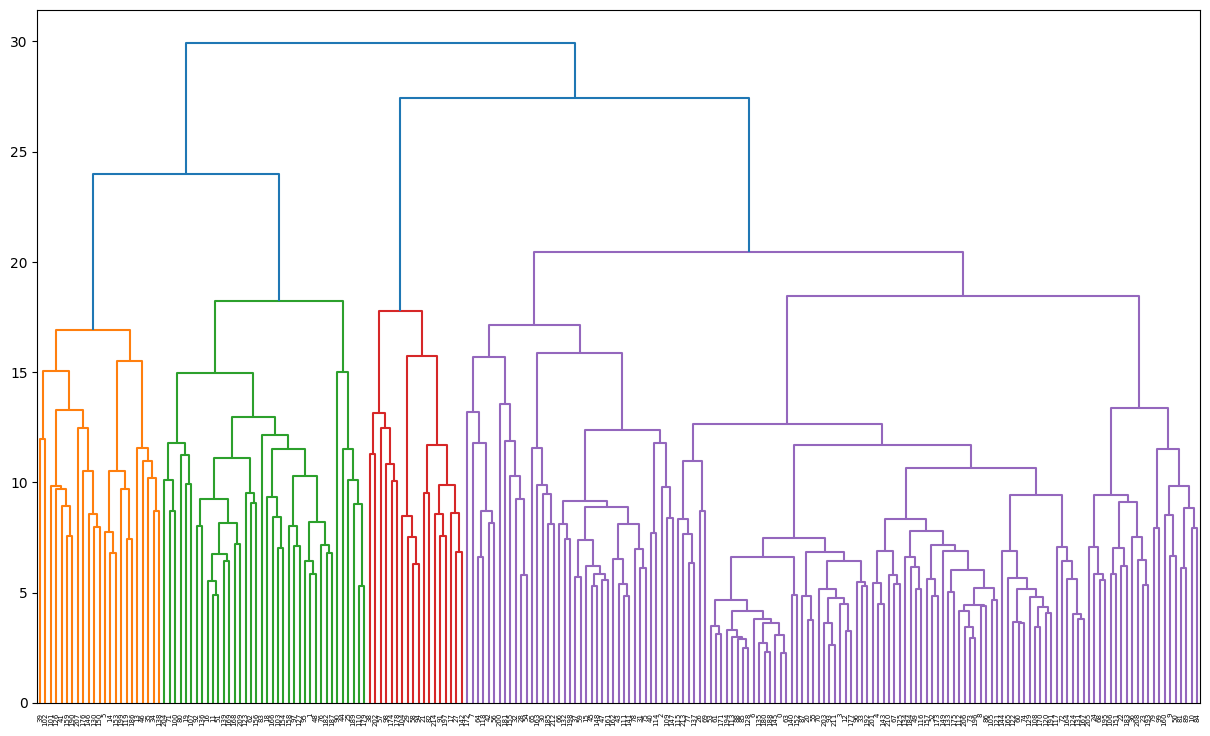

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

#dendrogram 시각화로 적절한 클러스터 사이즈를 예측해본다
#method="ward" -> 거리가 아닌 밀도기반
linked = linkage(list(df_cluster['vector']), method="ward")
plt.figure(figsize=(15,9))
dendrogram(linked)
plt.show()

In [ ]:
from tqdm import tqdm
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

scores = []
for i in tqdm(range(2,11)):
  agg = AgglomerativeClustering(n_clusters = i, linkage = 'ward')
  prediction = agg.fit_predict(list(df_cluster['vector']))
  score = silhouette_score(list(df_cluster['vector']),prediction)
  scores.append(score)

plt.plot(range(2,11),scores)

In [7]:
import gensim
from gensim import corpora, models
from gensim.corpora import Dictionary
import numpy as np

all_documents = list(df_cluster['token'])
dictionary = Dictionary(all_documents)
corpus = [dictionary.doc2bow(i) for i in all_documents]

ldamodel = gensim.models.ldamodel.LdaModel(corpus, num_topics = 4, id2word=dictionary, random_state=42)
align =[]
for i in ldamodel.get_document_topics(corpus):
  label = []
  value = []
  for t,v in i:
    label.append(t)
    value.append(v)
  align.append(label[np.argmax(value)])

df_cluster['topic'] = align

In [8]:
#visualize lda cluster
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

prepared_data = gensimvis.prepare(ldamodel, corpus, dictionary)
pyLDAvis.save_html(prepared_data, "ldavis_cluster_1.html")
pyLDAvis.display(prepared_data)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
df_cluster['topic'].value_counts()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,count
topic,
3,116
1,50
2,26
0,23


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
from collections import Counter
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

def calc_tfidf(df, label):
  all_document = []
  for i in df[label].unique():
    temp = df.loc[df[label] == i]['token']
    cluster_document = ''
    for w in temp:
      doc = " ".join(w)+' '
      cluster_document+=doc
    all_document.append(cluster_document)
  all_document[0]

  #tf-idf vectorizer
  vectorizer = TfidfVectorizer()
  tfidf = vectorizer.fit_transform(all_document)

  #transform to dataFrame
  feature_names = vectorizer.get_feature_names_out() #vocab
  tfidf = tfidf.toarray()


  tfidf = pd.DataFrame(tfidf, columns = feature_names)
  tfidf = tfidf.transpose() #swap row - col
  return tfidf


from collections import Counter
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

def calc_ratio(df, label):
  all_document = []
  for i in df[label].unique():
    temp = df.loc[df[label] == i]['token']
    cluster_document = ''
    for w in temp:
      doc = " ".join(w)+' '
      cluster_document+=doc
    all_document.append(cluster_document)

  cnt = []
  total = ''
  for i in all_document:
    cnt.append(dict(Counter(i.split())))
    total += i
  total = dict(Counter(total.split()))


  ratio = []
  for i in cnt:
    dic = {}
    for w in i:
      dic[w] = i[w]/total[w]
    ratio.append(dic)

  result = pd.DataFrame()
  num = 0
  for a, i in zip(cnt, ratio):
    temp = pd.DataFrame({'token':list(a.keys()),'count':list(a.values()),'ratio':list(i.values())})
    temp = temp.sort_values(by="count", ascending=False).iloc[:100].sort_values(by="ratio", ascending=False).reset_index(drop = True)
    temp.columns = [f'token {num}',f'count {num}',f'ratio {num}']
    result = pd.concat([result,temp], axis = 1)
    num +=1

  return result


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [16]:
cluster_tfidf = calc_tfidf(df_cluster,'topic')
cluster_tfidf.sort_values(by = 0,ascending=False).head(30)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,0,1,2,3
하다,0.871043,0.797050,0.873876,0.770702
있다,0.233745,0.184289,0.238743,0.279008
되다,0.140247,0.129002,0.120508,0.134930
보다,0.119279,0.140520,0.091708,0.132643
생각,0.109997,0.142824,0.121266,0.173808
같다,0.095217,0.085234,0.065939,0.096052
않다,0.089029,0.082930,0.084129,0.128069
시간,0.086967,0.103663,0.046233,0.057174
없다,0.078717,0.112877,0.090950,0.091478
좋다,0.073217,0.110573,0.078823,0.098339


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [18]:
cluster_ratio = calc_ratio(df_cluster, 'topic')
cluster_ratio.head(30)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,token 0,count 0,ratio 0,token 1,count 1,ratio 1,token 2,count 2,ratio 2,token 3,count 3,ratio 3
0,해,66,0.785714,복싱,11,1.000000,지역,45,0.918367,몬스터즈,19,1.000000
1,공부,162,0.771429,대학원,10,0.625000,사업,37,0.685185,이자,10,0.370370
2,이상,54,0.760563,헬스장,12,0.571429,사용,35,0.522388,직장,11,0.297297
3,계획,82,0.752294,수업,45,0.478723,글,68,0.438710,경험,11,0.289474
4,저,103,0.710345,타다,11,0.392857,소비,31,0.430556,끄다,11,0.261905
5,적다,58,0.698795,얘기,11,0.379310,만원,28,0.417910,점심,9,0.243243
6,독서,67,0.697917,프로젝트,12,0.352941,쓰다,104,0.403101,사진,15,0.238095
7,투자,72,0.692308,진행,11,0.297297,원,29,0.397260,마지막,10,0.232558
8,생,82,0.683333,끝나다,14,0.291667,써다,53,0.392593,직장인,23,0.216981
9,것,658,0.676259,재밌다,12,0.266667,필요하다,26,0.382353,대다,10,0.196078


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
#중간 저장
import pickle
with open('money_cluster1.pkl','wb') as file:
    pickle.dump(df,file)

In [ ]:
for i in df_cluster['topic'].unique():
  df_cluster.loc[df_cluster['topic'] == i].to_csv(f'topic_{i}.csv', encoding='utf-8')

In [ ]:
import json

with open('SentiWord_info.json', encoding= "utf-8-sig", mode = 'r') as f:
  sent_dicts = json.load(f)
sd = {i['word']:int(i['polarity']) for i in sent_dicts}


In [ ]:
def min_max(dic):
  result_dic = {}
  value = list(dic.values())
  minn = np.min(value)
  maxx = np.max(value)

  for k,v in dic.items():
    result_dic[k] = float((v-minn)/(maxx-minn))
  return result_dic

def sentiment_score(sent_dicts, token_list):
  result = [sd[i] for i in token_list if i in sd]
  return 0 if len(result) == 0 else np.mean(result)


def get_sents(df):
  df['sentiment'] = df['token'].apply(lambda x: sentiment_score(sd,x))

  action_sents = {}
  for i in df['topic'].unique():
    action_sents[int(i)] = float(np.mean(df.loc[df['topic'] == i]['sentiment']))

  normalized_action_sents = min_max(action_sents)
  print('sentiment', normalized_action_sents)
  return normalized_action_sents

def get_imps(ldamodel, corpus):
  prob = []
  for i in ldamodel.get_document_topics(corpus):
    temp = {i:0 for i in range(4)}
    for k,v in i:
      temp[k] = float(v)
    prob.append(list(temp.values()))

  value = np.array(prob).mean(axis=0)
  action_imp = {}
  for i in range(len(prob[0])):
    action_imp[i] = float(value[i])

  normalized_action_imp = min_max(action_imp)
  print('importance',normalized_action_imp)
  return normalized_action_imp

def get_opp(normalized_action_sents,normalized_action_imp):
  opportunity_score = {}
  for i in range(4):
    sat = normalized_action_sents[i]
    imp = normalized_action_imp[i]

    opportunity_score[i] = imp + float(np.max([imp-sat,0]))

  print('opportunity',opportunity_score)
  return opportunity_score

In [ ]:
sent = get_sents(df_cluster)
imp = get_imps(ldamodel,corpus)
opp = get_opp(sent, imp)

In [ ]:
import pandas as pd
sents_df = pd.DataFrame(columns = ['action','satisfaction', 'importance','opportunity'])

for i in range(4):
  sents_df.loc[len(sents_df)] = [f'cluster{1}action{i}',sent[i],imp[i],opp[i]]

sents_df

In [ ]:
actions = sents_df['action']
colors = np.random.rand(len(actions),3) #rgb내에서 리스트 길이만큼 랜덤 색깔 선택
imp = sents_df['importance']
sat = sents_df['satisfaction']

plt.figure(figsize=(17,10))

for i, action in enumerate(actions):
  plt.scatter(imp[i],sat[i],c = [colors[i]],label= action)

plt.legend(title='Actions', fontsize = 8, title_fontsize = 10, loc='best',bbox_to_anchor = (1,1))
plt.xlabel('Importance')
plt.ylabel('Satisfaction')

#만족도 기준선
x_data = [0,1]
y_data = [sat.mean(),1]
plt.plot(x_data, y_data, 'k-')

#중요도 기준선
x_data = [imp.mean(),1]
y_data = [0,1]
plt.plot(x_data, y_data, 'k-')

#legend for each point
texts = []
for i, action in enumerate(actions):
  texts.append(plt.text(imp[i], sat[i], action, fontsize = 13))

plt.grid(True)
plt.savefig('Opportunity area.png', dpi=300, bbox_inches='tight')